In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    RocCurveDisplay, roc_auc_score
)

RANDOM_STATE = 42
%matplotlib inline

## 1. Load the data

In [5]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## 2. Feature engineering: create the target variable

We compute tip percentage and split it at the median into "High" and "Low" classes.

In [7]:
df["tip_pct"] = df["tip"] / df["total_bill"]
median_pct = df["tip_pct"].median()
df["tip_class"] = np.where(df["tip_pct"] >= median_pct, "High", "Low")

print("Median tip percentage used as cutoff: {:.2%}".format(median_pct))
df["tip_class"].value_counts()

Median tip percentage used as cutoff: 15.48%


tip_class
Low     122
High    122
Name: count, dtype: int64

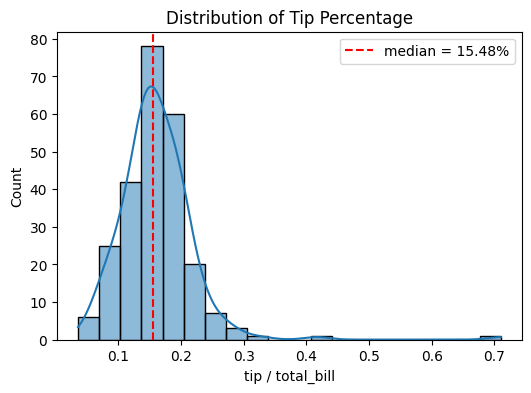

In [8]:
# Quick look at the distribution of tip percentage
plt.figure(figsize=(6,4))
sns.histplot(df["tip_pct"], bins=20, kde=True)
plt.axvline(median_pct, color="red", linestyle="--", label=f"median = {median_pct:.2%}")
plt.title("Distribution of Tip Percentage")
plt.xlabel("tip / total_bill")
plt.legend()
plt.show()

## 3. Define features (X) and target (y)

**Important:** `tip` and `tip_pct` are dropped from `X` because they were used to *create* the target — including them would leak the answer into the features.

In [9]:
feature_cols_num = ["total_bill", "size"]
feature_cols_cat = ["sex", "smoker", "day", "time"]

X = df[feature_cols_num + feature_cols_cat]
y = df["tip_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (195, 6)  Test shape: (49, 6)


## 4. Preprocessing

KNN is a **distance-based** algorithm, so scaling numeric features is essential (otherwise `total_bill`, ranging up to ~50, would dominate the distance calculation over 0/1 dummy variables). Numeric features are standardized; categorical features are one-hot encoded.

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_cols_num),
        ("cat", OneHotEncoder(drop="if_binary"), feature_cols_cat),
    ]
)

## 5. Build pipeline and tune K via cross-validated grid search

We search over the number of neighbors (K), the weighting scheme, and the distance metric using 5-fold cross-validation.

In [11]:
pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(3, 26, 2)),   # odd k from 3 to 25
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best hyperparameters:", grid.best_params_)
print("Best CV accuracy: {:.3f}".format(grid.best_score_))

Best hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 17, 'knn__weights': 'uniform'}
Best CV accuracy: 0.574


## 6. Evaluate on the held-out test set

In [12]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, list(best_model.classes_).index("High")]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score((y_test == "High").astype(int), y_proba)

print("Test Accuracy: {:.3f}".format(acc))
print("Test ROC-AUC : {:.3f}".format(auc))

Test Accuracy: 0.408
Test ROC-AUC : 0.396


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.40      0.32      0.36        25
         Low       0.41      0.50      0.45        24

    accuracy                           0.41        49
   macro avg       0.41      0.41      0.40        49
weighted avg       0.41      0.41      0.40        49



In [14]:
cm = confusion_matrix(y_test, y_pred, labels=["Low", "High"])
print("Confusion Matrix (rows=actual, cols=predicted) [Low, High]:")
print(cm)

Confusion Matrix (rows=actual, cols=predicted) [Low, High]:
[[12 12]
 [17  8]]


## 7. Visualize results: K vs accuracy, confusion matrix, ROC curve

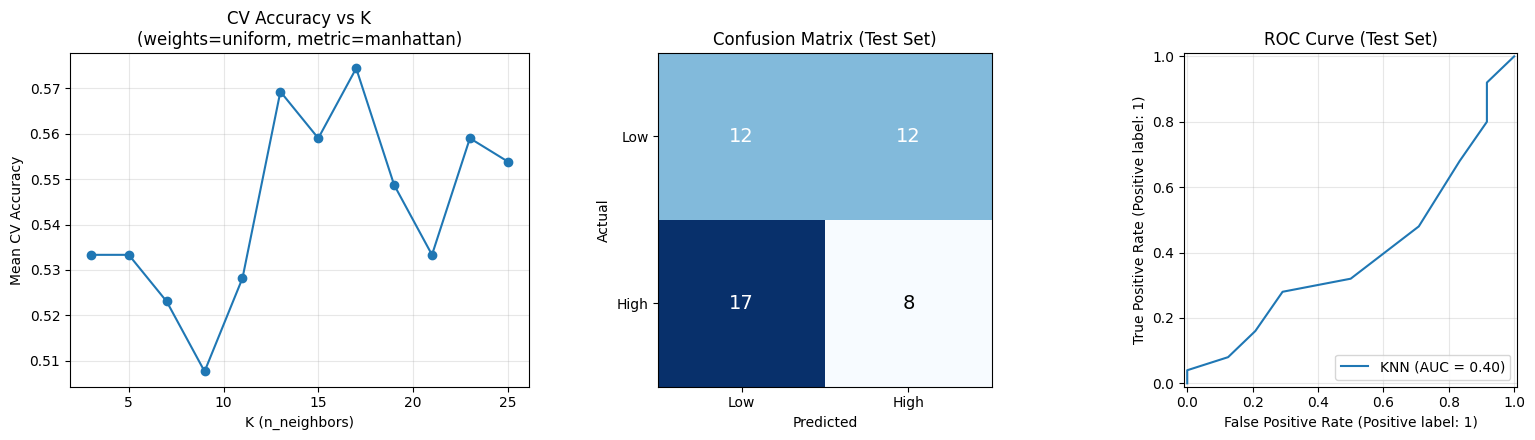

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 7a. Accuracy vs K (at the best weights/metric found)
results = pd.DataFrame(grid.cv_results_)
best_weights = grid.best_params_["knn__weights"]
best_metric = grid.best_params_["knn__metric"]
subset = results[
    (results["param_knn__weights"] == best_weights) &
    (results["param_knn__metric"] == best_metric)
].sort_values("param_knn__n_neighbors")

axes[0].plot(subset["param_knn__n_neighbors"], subset["mean_test_score"], marker="o")
axes[0].set_title("CV Accuracy vs K\n(weights={}, metric={})".format(best_weights, best_metric))
axes[0].set_xlabel("K (n_neighbors)")
axes[0].set_ylabel("Mean CV Accuracy")
axes[0].grid(alpha=0.3)

# 7b. Confusion matrix heatmap
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_title("Confusion Matrix (Test Set)")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Low", "High"])
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["Low", "High"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

# 7c. ROC curve
RocCurveDisplay.from_predictions(
    (y_test == "High").astype(int), y_proba, ax=axes[2], name="KNN"
)
axes[2].set_title("ROC Curve (Test Set)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("knn_tips_results.png", dpi=150)
plt.show()

## 8. Example: predict on a new customer

In [16]:
new_customer = pd.DataFrame([{
    "total_bill": 35.50,
    "size": 4,
    "sex": "Male",
    "smoker": "No",
    "day": "Sat",
    "time": "Dinner"
}])

pred_class = best_model.predict(new_customer)[0]
pred_proba = best_model.predict_proba(new_customer)[0]

print(new_customer.to_string(index=False))
print("Predicted tip class:", pred_class)
print("Class probabilities:", dict(zip(best_model.classes_, np.round(pred_proba, 3))))

 total_bill  size  sex smoker day   time
       35.5     4 Male     No Sat Dinner
Predicted tip class: Low
Class probabilities: {'High': np.float64(0.294), 'Low': np.float64(0.706)}


## 9. Bonus comparison: target = raw tip dollar amount

What if, instead of tip *percentage*, we predict whether the raw tip **dollar amount** is above or below the median?

Raw tip \$ correlates strongly with `total_bill` (bigger bills → bigger dollar tips even at a fixed tipping rate), so we'd expect this version to score noticeably higher — but it's a "weaker" business question, since it mostly just relearns that bigger bills get bigger dollar tips.

In [17]:
df["tip_class_amount"] = np.where(df["tip"] >= df["tip"].median(), "High", "Low")

Xb = df[feature_cols_num + feature_cols_cat]
yb = df["tip_class_amount"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=RANDOM_STATE, stratify=yb
)

grid_b = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_b.fit(Xb_train, yb_train)

acc_b = accuracy_score(yb_test, grid_b.predict(Xb_test))
print("Best params:", grid_b.best_params_)
print("CV accuracy: {:.3f}".format(grid_b.best_score_))
print("Test accuracy: {:.3f}".format(acc_b))

Best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
CV accuracy: 0.718
Test accuracy: 0.755


## 10. Interpretation

| Target | Test Accuracy |
|---|---|
| Tip **percentage** vs. median (primary) | ~0.41 |
| Raw tip **dollar amount** vs. median (bonus) | ~0.75 |

This gap is the key finding, not a bug:

- **Raw tip amount** is mostly just a proxy for `total_bill`, so predicting it is "easy" — the model is largely relearning "bigger bill → bigger tip."
- **Tip percentage** — the real measure of a customer's generosity — turns out to be only weakly related to bill size, party size, day, time, sex, or smoking status in this dataset. Accuracy near/below 50% (with K tuned via cross-validation across multiple metrics) shows tipping *rate* is close to random noise with respect to these features.

**Practical takeaway:** these features can roughly predict *dollar* tip size (because it tracks the bill), but they tell you almost nothing about whether someone is a *generous* tipper. That would require other signals not present in this dataset (e.g., service quality, repeat-customer history).